
## Business Understanding 

**1. Contexto do Problema**

O sucesso acadêmico de um estudante é o resultado de um ecossistema complexo. Ele não é definido exclusivamente pelo que acontece dentro da sala de aula, mas sim por uma intersecção de fatores comportamentais, ambientais, socioeconômicos e familiares. Instituições de ensino, professores e formuladores de políticas educacionais frequentemente enfrentam o desafio de identificar, de forma proativa, quais elementos estruturais e individuais mais impactam as notas dos alunos, dificultando a criação de intervenções eficazes.

**2. Oportunidade**

Com o avanço da análise de dados, temos a oportunidade de sair do "achismo" e utilizar métricas reais para entender a jornada educacional. Ao mapear o ambiente de aprendizagem, os recursos disponíveis, o histórico familiar e o comportamento individual, torna-se possível não apenas compreender o cenário atual, mas prever o desempenho futuro dos estudantes.

**3. Objetivos do Projeto**

Este projeto visa extrair inteligência acionável a partir de dados de nível estudantil, com os seguintes focos:

 * **Diagnóstico (Análise Exploratória):** Descobrir tendências e correlações fortes entre o estilo de vida do aluno (horas de sono, acesso à internet), o ambiente escolar (qualidade dos professores, tipo de escola) e o suporte familiar (envolvimento dos pais) em relação às suas notas.
 * **Predição (Machine Learning):** Desenvolver modelos preditivos capazes de estimar o resultado dos exames dos alunos com base em suas características, permitindo a identificação precoce de perfis de alto e baixo desempenho.

**4. Critérios de Sucesso**
O projeto será considerado bem-sucedido se entregar:

* Um conjunto claro de *insights* visuais que respondam quais variáveis têm o maior peso no sucesso ou fracasso acadêmico.
* Modelos de Regressão e/ou Classificação validados, estabelecendo uma base sólida (baseline) para prever o desempenho dos estudantes, provando o valor dos dados educacionais para a tomada de decisão.



In [ ]:
#Data Wraling
import pandas as pd
import numpy as np 

#Data vislualization
import matplotlib.pyplot as plt 
import seaborn as sns
from IPython.display import display

#Statistics
from scipy.stats import pearsonr, f_oneway
import statsmodels.api as sm

#Transform 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OrdinalEncoder, StandardScaler 

#Modelling 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score




In [110]:
#Definindo padrões em visuzalições 
sns.set_theme(
    style='whitegrid',    
    palette='deep',       
    context="notebook",   
    rc={
        "figure.figsize": (10, 6),      
        "axes.titlesize": 16,           
        "axes.labelsize": 12,           
        "axes.spines.top": False,       
        "axes.spines.right": False,     
        "grid.alpha": 0.4,              
        "legend.frameon": False         
    }
)

#Remove warning 
import warnings
warnings.filterwarnings('ignore')

In [111]:
#Load data 
df = pd.read_csv('../Data/Raw/StudentPerformanceFactors.csv')

In [112]:
#Primeiras linhas 
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



## Data Understanding (Dicionário de Dados)

O dataset possui 6.607 registros de alunos e é composto por 20 variáveis. Para facilitar a análise, estruturei as colunas por grandes grupos de influência:

**1. A Variável Alvo (Target)**

* **`Exam_Score`** *(Numérico - int)*: A nota final do aluno nos exames. Esta é a nossa estrela-guia. É o que tentaremos prever com os modelos de *Machine Learning*.

**2. Dedicação e Histórico Acadêmico**

* **`Hours_Studied`** *(Numérico - int)*: Total de horas dedicadas aos estudos (ex: 23, 19, 24).
* **`Attendance`** *(Numérico - int)*: Percentual de frequência/presença nas aulas.
* **`Previous_Scores`** *(Numérico - int)*: Notas anteriores do aluno. Fundamental para entender se o desempenho atual é uma constante ou um desvio.
* **`Tutoring_Sessions`** *(Numérico - int)*: Número de sessões de aulas particulares/reforço escolar que o aluno participou.
* **`Learning_Disabilities`** *(Categórico - Sim/Não)*: Indica se o aluno possui algum diagnóstico de dificuldade ou transtorno de aprendizagem.

**3. Hábitos Pessoais e Biológicos**

* **`Motivation_Level`** *(Categórico)*: Nível de motivação do aluno para com os estudos (`Low`, `Medium`, `High`).
* **`Sleep_Hours`** *(Numérico - int)*: Quantidade média de horas de sono.
* **`Physical_Activity`** *(Numérico - int)*: Nível ou frequência de atividade física praticada.
* **`Extracurricular_Activities`** *(Categórico - Sim/Não)*: Se o aluno participa de atividades fora da grade curricular normal.

**4. Contexto Familiar e Socioeconômico**

* **`Parental_Involvement`** *(Categórico)*: Nível de envolvimento dos pais na vida escolar (`Low`, `Medium`, `High`).
* **`Family_Income`** *(Categórico)*: Faixa de renda familiar do aluno (`Low`, `Medium`, `High`).
* **`Parental_Education_Level`** *(Categórico)*: Escolaridade dos pais (`High School`, `College`, `Postgraduate`). *Atenção: possui dados faltantes.*
* **`Access_to_Resources`** *(Categórico)*: Nível de acesso a recursos educacionais em casa (`Low`, `Medium`, `High`).
* **`Internet_Access`** *(Categórico - Sim/Não)*: Disponibilidade de acesso à internet.
* **`Distance_from_Home`** *(Categórico)*: Distância da residência até a escola (`Near`, `Moderate`, `Far`). *Atenção: possui dados faltantes.*

**5. Ambiente Escolar e Social**

* **`Teacher_Quality`** *(Categórico)*: Avaliação da qualidade dos professores (`Low`, `Medium`, `High`). *Atenção: possui dados faltantes.*
* **`School_Type`** *(Categórico)*: Tipo da instituição de ensino (`Public`, `Private`).
* **`Peer_Influence`** *(Categórico)*: Influência dos amigos/colegas sobre o aluno (`Positive`, `Negative`, `Neutral`).

**6. Demografia**

* **`Gender`** *(Categórico)*: Gênero do estudante (`Male`, `Female`).




### Diagnóstico Inicial

In [113]:
#Infos gerais 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

Como as colunas categóricas estão em 'str', vamos transformar as mesmas em 'category' para melhor desempenho.

##  Data Preparation & Cleaning

In [114]:
#Selecionando colunas 
str_cols = df.select_dtypes(include = ['str','object']).columns

#Lopp para transformar
for col in str_cols:
    df[col] = df[col].astype('category')
    
#Verificando novamente
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Hours_Studied               6607 non-null   int64   
 1   Attendance                  6607 non-null   int64   
 2   Parental_Involvement        6607 non-null   category
 3   Access_to_Resources         6607 non-null   category
 4   Extracurricular_Activities  6607 non-null   category
 5   Sleep_Hours                 6607 non-null   int64   
 6   Previous_Scores             6607 non-null   int64   
 7   Motivation_Level            6607 non-null   category
 8   Internet_Access             6607 non-null   category
 9   Tutoring_Sessions           6607 non-null   int64   
 10  Family_Income               6607 non-null   category
 11  Teacher_Quality             6529 non-null   category
 12  School_Type                 6607 non-null   category
 13  Peer_Influence              6

### Tratamento de Dados Faltantes (Nulos) e Duplicatas

In [115]:
#Dados nulos 
nulos = df.isnull().sum()
print(nulos)


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [116]:
#Porcentagem de nulos no df 
nulos / len(df) * 100

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64

In [117]:
#Vendo linhas com os nulos 
df[df.isnull().any(axis = 1)]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
33,14,60,High,Medium,No,5,50,Medium,Yes,2,Medium,Medium,Public,Neutral,3,No,College,NaN,Female,61
127,17,97,Medium,Medium,No,8,89,Medium,Yes,1,Low,NaN,Public,Neutral,4,No,High School,Far,Male,69
240,15,87,Low,Medium,No,4,54,Medium,Yes,1,Medium,Medium,Public,Neutral,6,No,NaN,Moderate,Male,65
275,23,82,Low,Medium,Yes,8,94,Medium,Yes,1,Medium,Medium,Public,Negative,2,Yes,High School,NaN,Male,66
316,24,90,Low,Low,No,7,83,Medium,Yes,0,Low,Medium,Private,Positive,3,No,College,NaN,Male,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6502,23,64,Medium,Medium,No,7,75,Medium,Yes,2,Medium,High,Public,Positive,2,No,NaN,Near,Female,66
6579,9,84,Medium,Medium,No,6,74,Medium,Yes,5,High,NaN,Public,Neutral,2,No,High School,Near,Male,67
6589,22,90,Low,High,No,5,99,Medium,Yes,1,Low,Low,Private,Positive,2,No,College,NaN,Female,70
6594,9,90,High,High,Yes,7,79,Low,Yes,4,High,High,Public,Positive,4,No,High School,NaN,Male,70


Optmos por excluir as linhas com valores nulos (dropna) pois elas representavam apenas 3.4% da base de dados, preservando assim a distribuição original das categorias sem introduzir viés de imputação.

In [118]:
#Dropando nulos 
df.dropna(inplace = True)

#Verificando novamente 
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [119]:
#Dados duplicados 
df.duplicated().sum()

np.int64(0)

## Análise Exploratória de Dados (EDA)

Nesta etapa de Análise Exploratória, nosso objetivo é investigar o comportamento da nossa variável alvo e descobrir quais fatores têm maior correlação com o sucesso acadêmico. Nossa análise será dividida nas seguintes frentes:

 * A Variável Alvo (Exam_Score): Entender a distribuição geral das notas dos alunos (se a maioria vai bem, mal, ou se segue uma distribuição normal).

 * Fatores Acadêmicos (Hours_Studied, Attendance, Previous_Scores): Avaliar o impacto direto do esforço do aluno e da assiduidade nas notas finais.

 * Comportamento e Hábitos (Motivation_Level, Sleep_Hours): Descobrir se alunos mais motivados e que dormem mais realmente performam melhor.

 * Contexto Familiar e Escolar (Parental_Involvement, Access_to_Resources, Teacher_Quality): Medir o peso da estrutura familiar e da qualidade do ensino no resultado dos exames.

## Análise Univariada

### **Variáveis Numéricas**

In [120]:
df.info()

<class 'pandas.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Hours_Studied               6378 non-null   int64   
 1   Attendance                  6378 non-null   int64   
 2   Parental_Involvement        6378 non-null   category
 3   Access_to_Resources         6378 non-null   category
 4   Extracurricular_Activities  6378 non-null   category
 5   Sleep_Hours                 6378 non-null   int64   
 6   Previous_Scores             6378 non-null   int64   
 7   Motivation_Level            6378 non-null   category
 8   Internet_Access             6378 non-null   category
 9   Tutoring_Sessions           6378 non-null   int64   
 10  Family_Income               6378 non-null   category
 11  Teacher_Quality             6378 non-null   category
 12  School_Type                 6378 non-null   category
 13  Peer_Influence              6378 n

#### Medidas de Tendência Central e Variabilidade

In [121]:
#Selecionando colunas numéricas 
num_cols = df.select_dtypes(include = 'int')
num_cols = num_cols.drop('Physical_Activity', axis = 1)

#Estatísticas 
num_cols.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Exam_Score
count,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000
mean,19.977109,80.020853,7.034964,75.066165,1.495296,67.252117
std,5.985460,11.550723,1.468033,14.400389,1.233984,3.914217
min,1.000000,60.000000,4.000000,50.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,101.000000


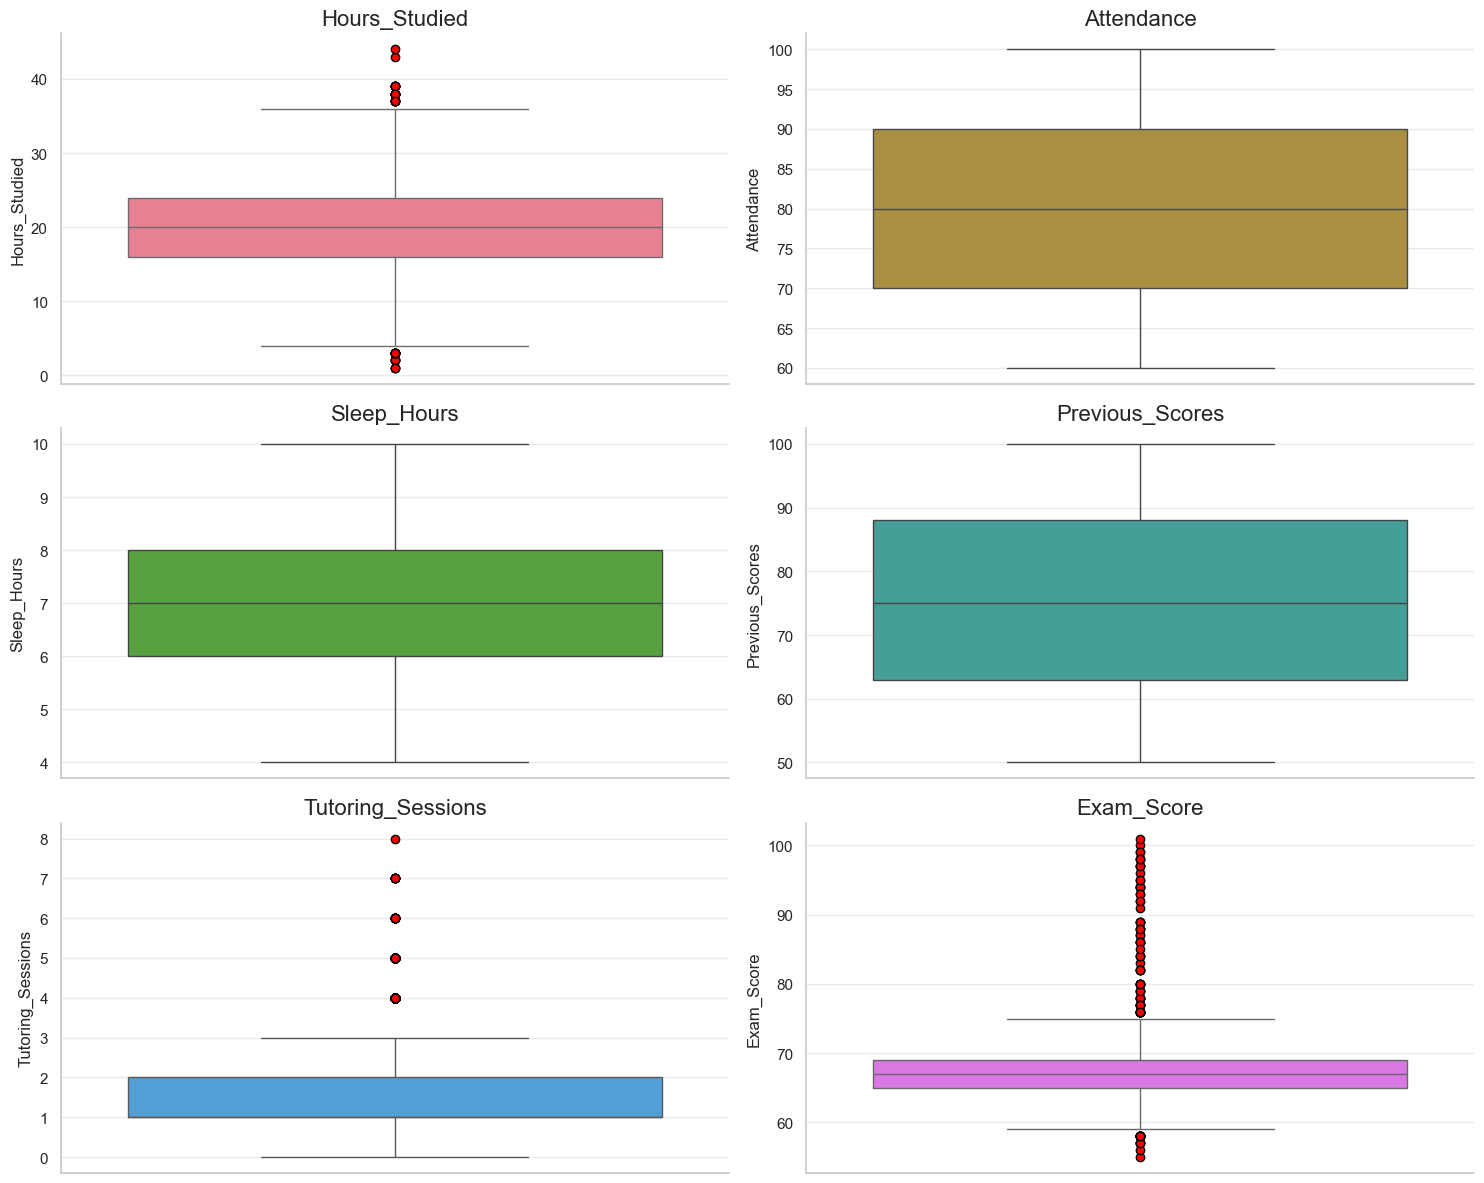

In [122]:
colunas = num_cols.columns
n = len(colunas)
cores = sns.color_palette("husl", n)

#Defininindo tamanho da imagem
plt.figure(figsize=[15, 12])

#Enumerate para subplots
for i, col in enumerate(colunas):
    #Boxplot com subplots
    plt.subplot(3, 2, i + 1) 
    sns.boxplot(df[col], color=cores[i], flierprops = {
        'marker' : 'o',
        'markerfacecolor' : 'red',
        'markeredgecolor' : 'black'
    })
    plt.title(col)
    plt.xlabel('')

plt.tight_layout()
plt.show()

Insights: Tendência Central + Variabilidade

**Hours_Studied**:

 * Tendência Central: A média (19.97) e a mediana (20) são praticamente idênticas, indicando uma distribuição perfeitamente simétrica.

 * Variabilidade: Metade da turma (IQR) tem um padrão sólido de estudo, variando apenas 8 horas (entre 16h e 24h). O desvio padrão é de quase 6h, o que é moderado.

**Attendance:**

 * Tendência Central: Média e mediana cravadas em 80.

 * Variabilidade: Há uma dispersão considerável (desvio padrão de 11.5), mas muito bem distribuída. Exatos 50% dos alunos têm presença entre 70% e 90%. Como o mínimo é 60 e o máximo é 100, os "bigodes" do boxplot absorvem todos os dados, confirmando a ausência de outliers.

**Sleep_Hours**:

 * Tendência Central: Média (7.03) e mediana (7.0) iguais.

 * Variabilidade: Dispersão baixíssima (desvio padrão de 1.4). A turma é extremamente regrada com o sono, com o bloco central variando apenas entre 6h e 8h.

**Previous_Scores:**

 * Tendência Central: Média (75.06) e mediana (75) iguais.

 * Variabilidade: É a variável com maior variabilidade do dataset (desvio padrão de 14.4). As notas anteriores vão de 50 a 100, e a "caixa" central é bem larga (de 63 a 88), indicando que o histórico dos alunos é bastante diverso.

**Tutoring_Sessions**:

 * Tendência Central: Aqui temos uma diferença! A média (1.49) é maior que a mediana (1.0). Isso prova matematicamente a assimetria (skewness) que os outliers vermelhos causaram puxando a média para cima.

 * Variabilidade: Baixíssima. O 3º quartil (75%) é de apenas 2 sessões. Qualquer aluno que faça mais de 3 ou 4 sessões já é estatisticamente uma exceção.

**Exam_Score**:

 * Tendência Central: Média (67.2) e mediana (67) praticamente juntas.

 * Variabilidade: Variabilidade baixíssima (desvio padrão de apenas 3.9). Impressionantes 50% da turma (a caixa do boxplot) tirou notas num intervalo minúsculo de 4 pontos (entre 65 e 69). O máximo de 101 (nota bônus?) e o mínimo de 55 explicam perfeitamente os outliers que vimos no gráfico.

#### Distribuição 

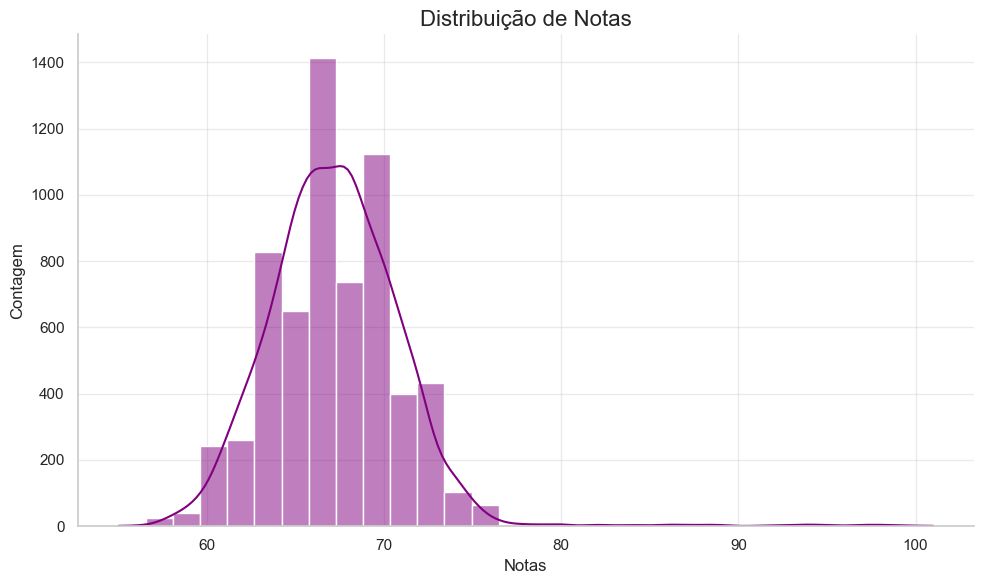

In [123]:
#Distribuição da coluna target
sns.histplot(df['Exam_Score'], bins = 30, color= 'purple', kde = True)

#Título e eixos 
plt.title('Distribuição de Notas')
plt.xlabel('Notas')
plt.ylabel('Contagem')

plt.tight_layout()
plt.show()


Análise da distribuição de notas 

* Formato de Sino (Normalidade): A distribuição segue um formato muito claro de sino, indicando uma distribuição normal (gaussiana). Isso explica o motivo da média e da mediana serem tão próximas.

* Alta Concentração (Pico/Moda): A curva é bastante "esguia" e pontuda. Observe a barra mais alta (a moda): uma quantidade massiva de alunos (quase 1.400) tirou notas exatamente ali, na faixa dos 66 a 68 pontos. A grande massa de dados está espremida entre 60 e 75.

* Cauda à Direita (Outliers visíveis): O gráfico se comporta de modo que depois das notas 80 no eixo X, a linha roxa fica quase achatada no chão (indicando uma contagem baixíssima de alunos), mas se arrasta até passar de 100. Essa cauda longa é a tradução literal daqueles pontos vermelhos do boxplot: pouquíssimos alunos destoaram da sala e tiraram notas altíssimas.

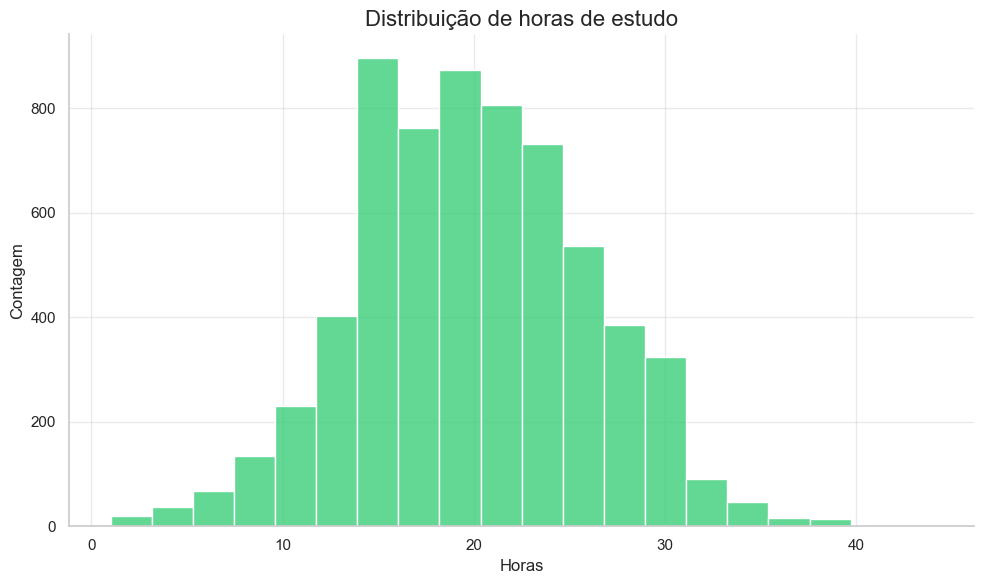

In [124]:
#Ditribuição de horas de estudo
sns.histplot(df['Hours_Studied'], bins = 20, color = '#2ECC71')

#Título e eixos 
plt.title('Distribuição de horas de estudo')
plt.xlabel('Horas')
plt.ylabel('Contagem')

plt.tight_layout()

Insights da Distribuição de Horas de Estudo

* Distribuição Normal (O "Sino" Perfeito): O gráfico forma uma curva de sino quase impecável. Isso mostra uma simetria fantástica nos dados, comprovando visualmente o porquê da média e da mediana serem idênticas (em torno de 20 horas). O comportamento da turma é super previsível.

* Forte Concentração no Centro: A esmagadora maioria dos alunos (o "grosso" das barras) está concentrada no intervalo entre 15 e 25 horas. Esse é o padrão absoluto de esforço dessa turma.

* A Origem dos Outliers: Lembra dos pontinhos vermelhos no boxplot de Hours_Studied? Neste histograma, eles são representados por essas barrinhas muito baixinhas nas extremidades. Perceba como quase ninguém estuda menos de 5 horas (extrema esquerda) ou mais de 35 horas (extrema direita). São exceções raras.

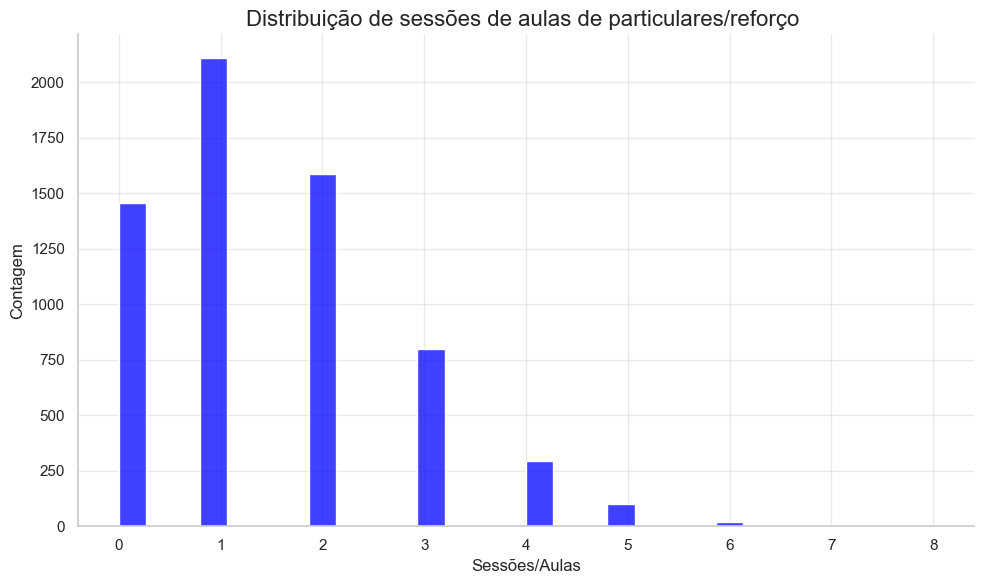

In [125]:
#Distribuição de aulas de reforço/particulares
sns.histplot(df['Tutoring_Sessions'], bins = 30, color= 'blue')

#Título e eixos 
plt.title('Distribuição de sessões de aulas de particulares/reforço ')
plt.xlabel('Sessões/Aulas')
plt.ylabel('Contagem')

plt.tight_layout()

Insights da Distribuição de aulas particulares:

* Assimetria à Direita: O gráfico é uma escadinha que desce rapidamente para a direita. Isso prova visualmente o motivo de a média ser puxada para cima e por que o boxplot acusou tantos outliers.

* Padrão da Maioria: A esmagadora maioria dos alunos está concentrada nas barras de 0, 1 e 2 sessões. O pico absoluto (a Moda) é de exatamente 1 sessão de reforço (mais de 2.000 alunos).

* Forte presença do "Zero": Quase 1.500 alunos simplesmente não fazem nenhuma sessão de reforço. É o segundo grupo mais comum da base de dados.

* Exceções à Regra: A partir de 4 sessões, a contagem despenca drasticamente. Quem faz 5, 6, 7 ou 8 sessões representa uma parcela microscópica da turma (aqueles pontinhos vermelhos que vimos antes).

### **Variáveis Categóricas**

* Comportamento e Hábitos (Motivation_Level): Descobrir se os alunos estão mais motivados.

* Contexto Familiar e Escolar (Parental_Involvement, Access_to_Resources, Teacher_Quality): Medir o peso da estrutura familiar e da qualidade do ensino no resultado dos exames.

In [126]:
#Selecionando variáveis categóricas para análise
cols_to_analyze = ['Motivation_Level','Parental_Involvement','Access_to_Resources','Teacher_Quality']

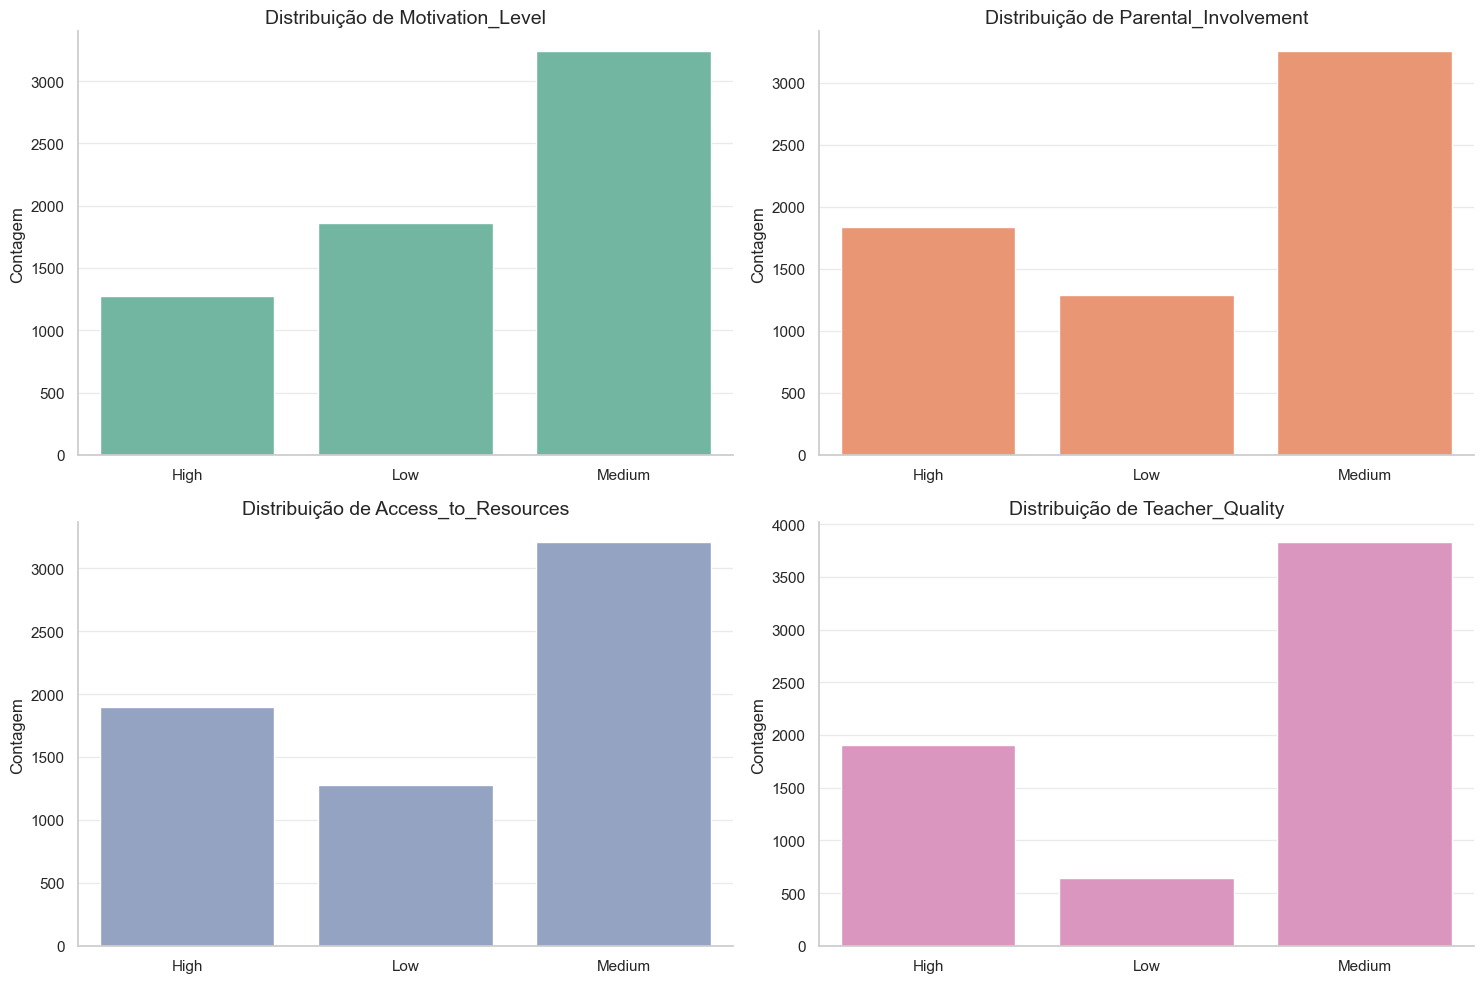

In [127]:
#Definindo o tamano da lista e cores
n = len(cols_to_analyze)
cores = sns.color_palette("Set2", n) #paleta melhor para dados categoricos

#Defininindo tamanho da imagem
plt.figure(figsize=[15, 10])

#Enumerate para subplots
for i, col in enumerate(cols_to_analyze):
    #Countplots com subplots
    plt.subplot(2, 2, i + 1) 
    sns.countplot(x = df[col], color = cores[i]
    )
    
    #Títulos e eixos
    plt.title(f'Distribuição de {col}', fontsize=14)
    plt.xlabel('')           
    plt.ylabel('Contagem')   

plt.tight_layout()
plt.show()

#### **Insights das Variáveis Categóricas**

Motivation_Level (Nível de Motivação):

* O Alerta: É a única variável onde o nível Baixo (Low) é maior que o nível Alto (High).

* Insight: A maioria tem motivação média, mas entre os extremos, temos mais alunos desmotivados do que altamente engajados. Isso pode ser um fator crucial para cruzar com as notas depois!

Parental_Involvement (Envolvimento dos Pais):

* Padrão Positivo: Ao contrário da motivação, aqui o cenário se inverte para o bem. Depois da grande massa no nível "Médio", temos muito mais pais com Alto envolvimento do que com baixo.

Access_to_Resources (Acesso a Recursos):

* Espelho: O comportamento dessa variável é praticamente um "copiar e colar" do envolvimento dos pais. A maioria tem recursos médios, seguidos por recursos altos e, por último, a minoria tem poucos recursos.

Teacher_Quality (Qualidade do Professor):

* A Maior Concentração: É a categoria com a barra "Medium" mais alta de todas (quase 4.000 registros).

* Insight: A avaliação dos professores é bem segura. Praticamente não existem professores classificados como de qualidade Baixa (Low) (a barra é minúscula). O ensino é, no geral, considerado na média ou alto.

In [128]:
#Contando exatamente quantos alunos existem em cada nível de atividade física
contagem_atividade = df['Physical_Activity'].value_counts().sort_index()
print(contagem_atividade)

Physical_Activity
0      44
1     400
2    1562
3    2460
4    1535
5     346
6      31
Name: count, dtype: int64


In [129]:
#Remeando valores na coluna atividade física
mapping = {
    0 : 'None',
    1 : 'Very Low',
    2 : 'Low',
    3 : 'Moderate',
    4 : 'Active',
    5 : 'Very Active',
    6 : 'Athlete'
}

# Aplicando na coluna 
df['Physical_Activity'] = df['Physical_Activity'].replace(mapping)

#Deixando em ordem 
df['Physical_Activity'] = pd.Categorical(df['Physical_Activity'], categories = list(mapping.values()), ordered= True)

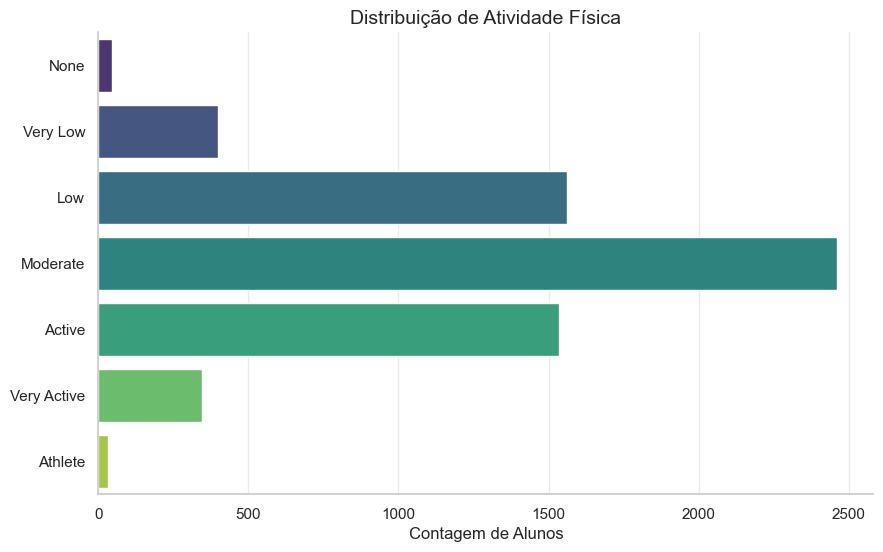

In [130]:
#Tamanho da figura
plt.figure(figsize=(10, 6))

#Usamos o countplot Passando no eixo 'y' para as barras ficarem deitadas
sns.countplot(y= df['Physical_Activity'], palette='viridis')

#Adicionando título e limpando os eixos
plt.title('Distribuição de Atividade Física', fontsize=14)
plt.xlabel('Contagem de Alunos')
plt.ylabel('') 
 
#Removendo bordassns.despine() 
plt.show()

Insights da Distribuição de Atividade Física

* O "Sino" Categórico: Assim como vimos nas Notas e nas Horas de Estudo, a Atividade Física também forma uma curva de sino (distribuição normal) perfeita. Isso mostra que os hábitos de saúde dessa turma são super equilibrados e previsíveis.

* A Maioria "Moderada": O pico absoluto da turma é o nível Moderate, englobando quase 2.500 alunos. O aluno padrão dessa escola tem uma rotina de exercícios mediana e saudável.

* Simetria Impressionante: Note como os blocos adjacentes se espelham. Quem é Active e quem tem Low activity empatam na faixa dos 1.500 alunos. Descendo mais um degrau, os níveis Very Active e Very Low também têm tamanhos bem parecidos (na faixa de 300 a 400 alunos).

* Os Extremos são Raros: Ao contrário do gráfico anterior que mostrava contagens altas para tudo, aqui vemos a realidade: ser totalmente sedentário (None) ou ser um atleta de ponta (Athlete) é uma exceção rara na sua base de dados (ambos com menos de 100 alunos).

## Análise Bivariada

#### **Variáveis numéricas**

In [131]:
#Correlações
correlation_matrix = num_cols.corr()
correlation_matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Exam_Score
Hours_Studied,1.000000,-0.004997,0.013119,0.022492,-0.009654,0.445104
Attendance,-0.004997,1.000000,-0.019602,-0.018083,0.012070,0.580259
Sleep_Hours,0.013119,-0.019602,1.000000,-0.023238,-0.011466,-0.017171
Previous_Scores,0.022492,-0.018083,-0.023238,1.000000,-0.013158,0.174283
Tutoring_Sessions,-0.009654,0.012070,-0.011466,-0.013158,1.000000,0.156829
Exam_Score,0.445104,0.580259,-0.017171,0.174283,0.156829,1.000000


<Axes: >

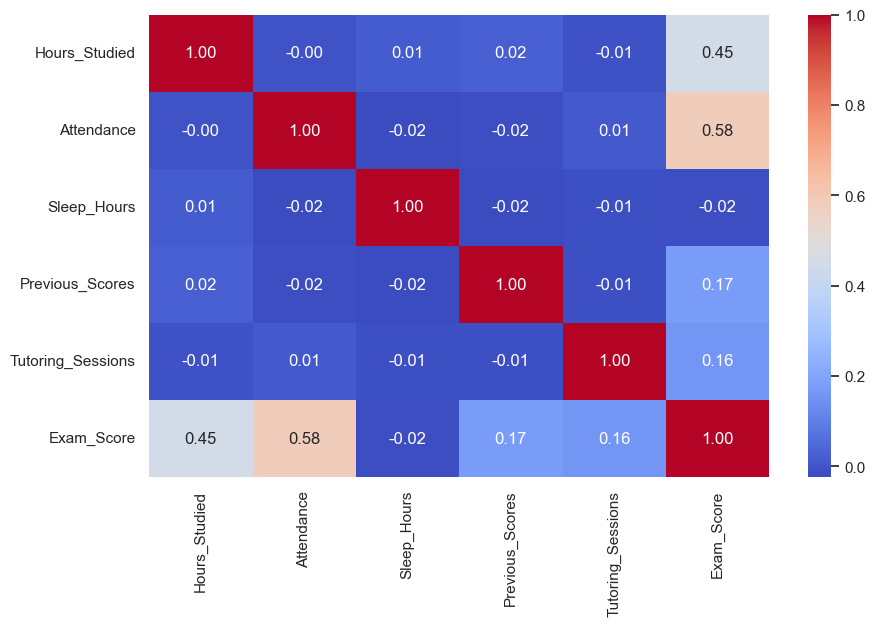

In [132]:
#Heatmap 
sns.heatmap(correlation_matrix, annot = True, cbar = True, cmap = 'coolwarm', fmt = '.2f')



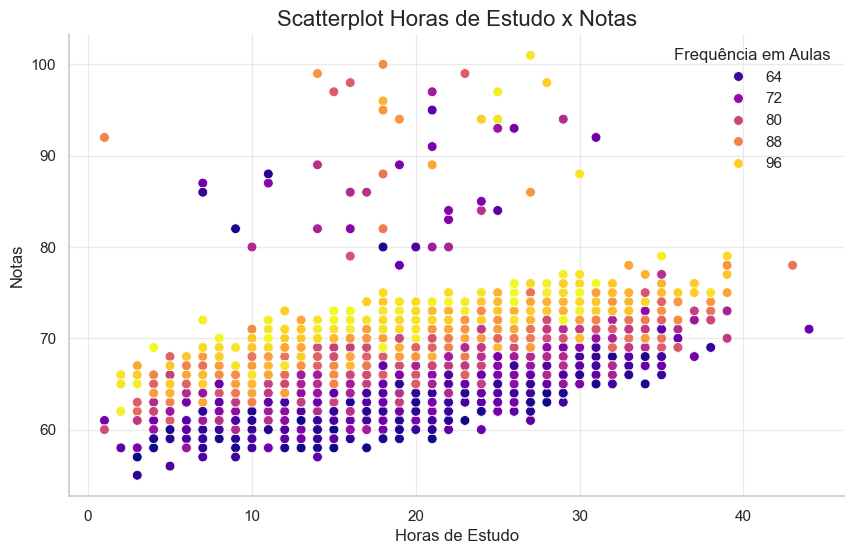

In [133]:
#Gráfico de dispersão 
ax = sns.scatterplot(x = df['Hours_Studied'], y = df['Exam_Score'], s = 50, palette= 'plasma', hue = df['Attendance'] )

#Títulos e eixos 
plt.title('Scatterplot Horas de Estudo x Notas')
plt.xlabel('Horas de Estudo')
plt.ylabel('Notas')
plt.legend(title = 'Frequência em Aulas')


### Insights da Matriz de Correlação (Heatmap)

* **O "Rei" das Notas (Attendance):** A variável que mais impacta a nota final (`Exam_Score`) não é o estudo em casa, mas sim a **Frequência em Aulas** (correlação de **0.58**). É uma correlação positiva forte para dados educacionais. Quem vai à aula, passa.
* **O "Príncipe" (Hours_Studied):** As **Horas de Estudo** vêm em segundo lugar (correlação de **0.45**). Estudar ajuda bastante, mas os dados mostram que de nada adianta estudar muito se o aluno falta às aulas.
* **As Decepções (Tutorias e Sono):** Desconfiávamos que as tutorias (`Tutoring_Sessions`) explicariam os *outliers*, a correlação de apenas **0.16** diz que o impacto é bem fraco. E o sono (`Sleep_Hours`) zerou (**-0.02**), indicando que dormir mais ou menos não alterou em nada a nota dessa turma.
* **Ausência de Multicolinearidade:** Nenhuma variável preditora tem correlação forte com outra (tudo na casa do `0.00` a `0.02`). Isso é um **cenário perfeito para Machine Learning**, pois significa que cada coluna traz uma informação única e independente para o modelo.

### Insights do Gráfico de Dispersão (Scatterplot)

* **Efeito "Camadas de Bolo" (Estratificação):** Esse é o achado mais visual! Podemos ver a massa de dados concentrada entre as notas 60 e 80. As cores formam "listras" horizontais perfeitas. Os pontos amarelos (Alta Frequência: 96) estão sempre no topo da faixa, enquanto os pontos roxos escuros (Baixa Frequência: 64) formam o "chão" das notas.
* **A Combinação Vencedora:** O gráfico cruza perfeitamente as duas maiores correlações. À medida que você vai para a direita (estuda mais), a nota base sobe. Mas, independentemente de estudar 10 ou 30 horas, se o ponto for amarelo (alta presença), ele estará acima dos roxos.
* **Os Gênios (Outliers):** Aqueles pontos espalhados lá em cima (notas 80 a 100) confirmam o que vimos no *boxplot* anterior. Eles fogem do padrão das "camadas". Temos alunos ali tirando notas acima de 90 com apenas ~5 horas de estudo, e alguns deles até com frequências mais baixas (pontos roxos/rosas perdidos no topo). Isso indica que existe algum outro fator (talvez a motivação ou qualidade do professor) que impulsionou esses *outliers*.



**Resumo:** Para tirar boas notas nessa escola, a regra de ouro é **não faltar**. Estudar é o segundo passo.



#### **Variáveis categóricas**

In [134]:
#Selecionando variáveis categóricas para análise
cols_to_analyze = ['Motivation_Level','Parental_Involvement','Access_to_Resources','Teacher_Quality']

In [135]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,Moderate,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,Active,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,Active,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,Active,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,Active,No,College,Near,Female,70


In [136]:
#Tabela de contigencia Envolvimento dos Pais x Motivação (contagem absoluta)
contigency_table = pd.crosstab(df['Parental_Involvement'], df['Motivation_Level'])
contigency_table

Motivation_Level,High,Low,Medium
Parental_Involvement,,,
High,347,553,936
Low,271,355,665
Medium,659,956,1636


In [137]:
#Tabela de contigencia Envolvimento dos Pais x Motivação (contagem relativa)
percent_table = pd.crosstab(df['Parental_Involvement'], df['Motivation_Level'], normalize= 'index') *100
percent_table

Motivation_Level,High,Low,Medium
Parental_Involvement,,,
High,18.899782,30.119826,50.980392
Low,20.991479,27.498064,51.510457
Medium,20.270686,29.406337,50.322978


Text(67.25, 0.5, 'Envolvimento dos Pais')

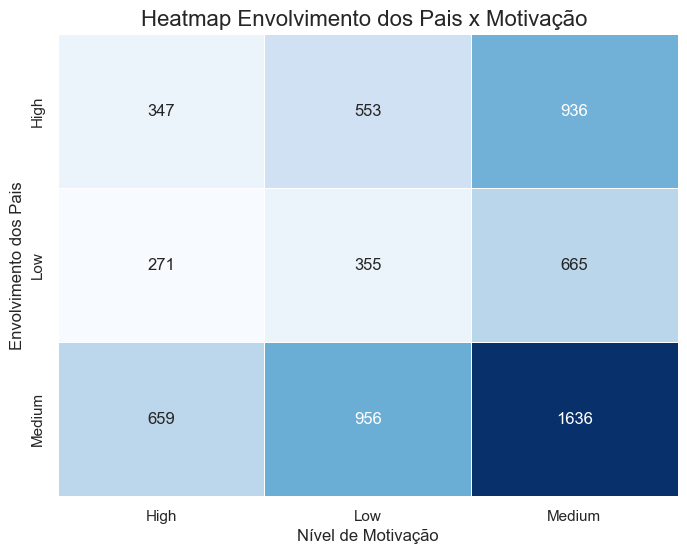

In [138]:
#Plotando a tabela visualmente (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(contigency_table, annot=True, fmt="d", cmap="Blues", linewidths=0.5, cbar=False)

#Títulos e eixos 
plt.title('Heatmap Envolvimento dos Pais x Motivação ')
plt.xlabel('Nível de Motivação')
plt.ylabel('Envolvimento dos Pais')


### Insights: Envolvimento dos Pais vs. Motivação

* **O Império da Média:** O quadrado mais escuro (1.636 alunos) confirma a regra de ouro da sua base de dados. A combinação disparada mais comum da escola inteira é o combo "médio": pais com envolvimento mediano e alunos com motivação mediana.
* **A Quebra de Expectativa:** O senso comum sugere que pais super presentes (`High`) geram alunos super motivados (`High`), certo? **Nesta base de dados, não.** Olhe para a linha superior (Pais `High`): a grande maioria dos filhos deles tem motivação `Medium` (936) ou até mesmo `Low` (553). O cruzamento perfeito de `High x High` tem apenas 347 alunos.
* **A Origem da Alta Motivação:** Se você olhar de cima para baixo na coluna de Alta Motivação (`High`), vai perceber que a maior parte dos alunos mais empolgados da escola (659 alunos) vem de famílias com envolvimento apenas `Medium`.

**Resumo:** O envolvimento extremo dos pais não está se traduzindo em alta motivação para os alunos. O equilíbrio (o meio termo) domina as duas frentes.


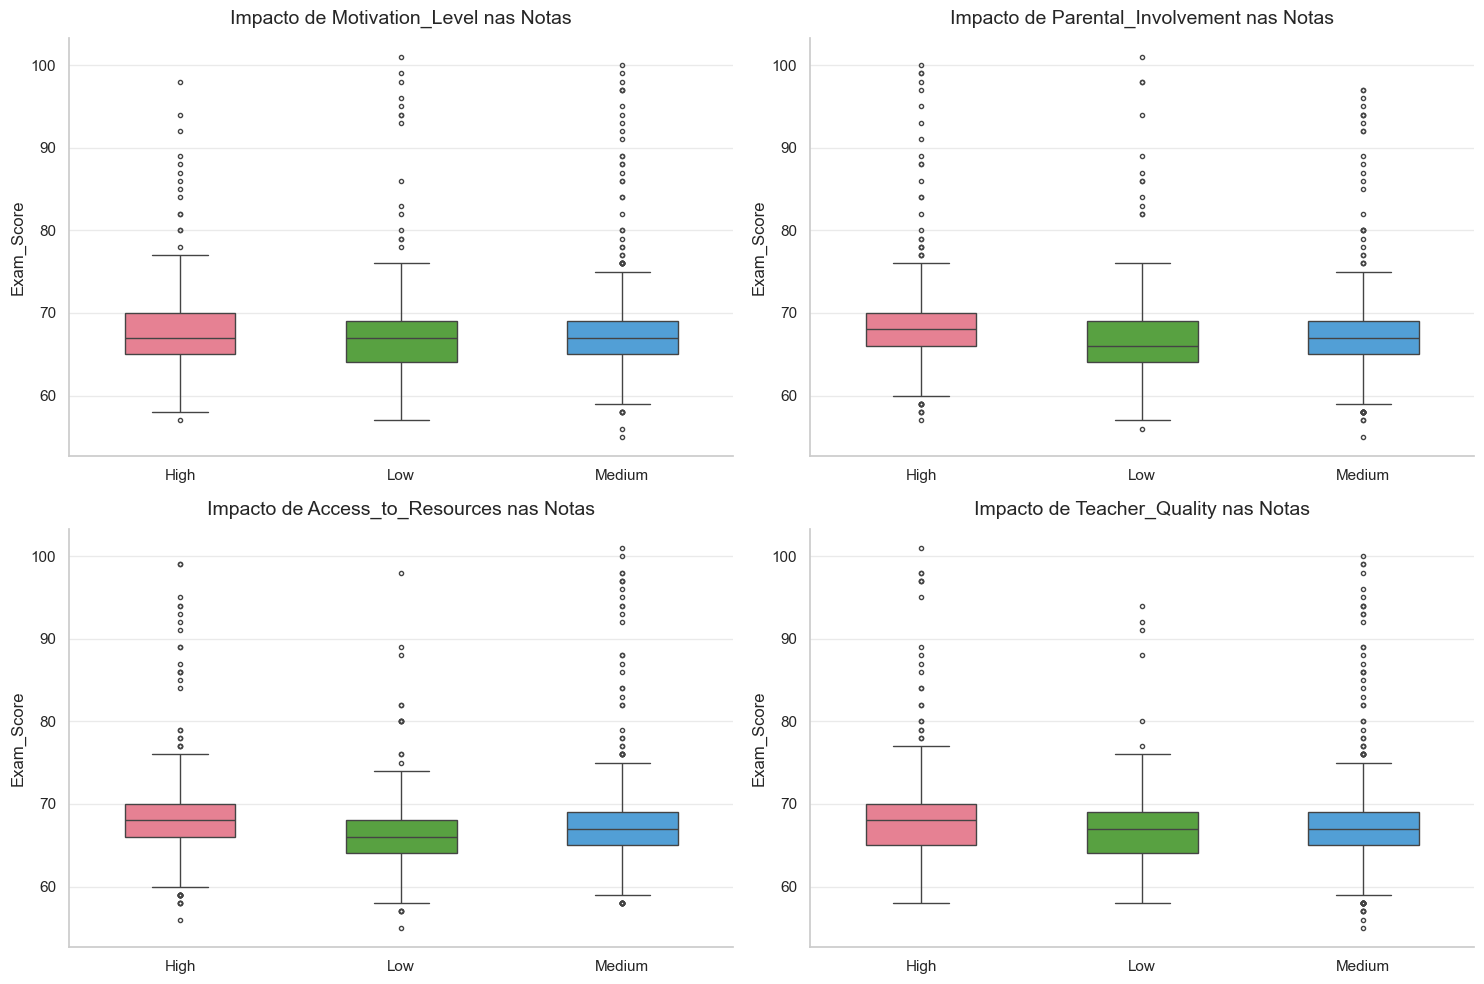

In [139]:
#Tamanho do gráfico
plt.figure(figsize=(15,10))

#For enumerate p percorres todas as colnas 
for i, col in enumerate(cols_to_analyze):
    plt.subplot(2,2, i + 1)
    
    #Boxplot
    sns.boxplot(x = df[col], y = df['Exam_Score'], palette= 'husl', width = 0.5, fliersize= 3)
    
    plt.title(f'Impacto de {col} nas Notas', fontsize=14, pad=10)
    plt.xlabel('')

#Limpando as bordas e ajustando o espaçamento
sns.despine()
plt.tight_layout()
plt.show()


### Insights: Categorias vs. Notas 

* **O Império da Estabilidade:** O achado mais gritante aqui é que **as caixas são quase idênticas**. Independentemente de o aluno ter Motivação *High*, *Medium* ou *Low*, a linha central (Mediana) continua ali, cravada na faixa dos 67 a 69 pontos. A base das notas não muda drasticamente.
* **A "Escadinha" Microscópica:** Se olhar com uma lupa para `Access_to_Resources` e `Teacher_Quality`, até existe uma minúscula escadinha (a mediana do *High* é um "pelinho" mais alta que a do *Low*). Mas a diferença é tão sutil (talvez 1 ou 2 pontos) que o impacto real no boletim é quase irrelevante se comparado a estudar mais horas.
* **A Revelação dos Outliers (Os "Gênios"):** Antes queríamos saber onde estavam escondidos os alunos que tiraram notas entre 85 e 100, e a resposta é: **Em todos os lugares!** Existem outliers nas alturas até mesmo nas categorias *Low* de Motivação, Envolvimento dos Pais e Qualidade do Professor.

**O Resumo:**
Esses gráficos provam por A mais B que **fatores externos e psicológicos (categorias) quase não impactam a nota final dessa turma**. O aluno não precisa de pais super presentes, recursos de ponta ou motivação extrema para tirar uma nota alta.

A receita do sucesso dessa escola já havia sido revelada no nosso Heatmap e Scatterplot anteriores: **Sente na cadeira, assista às aulas (Attendance) e estude em casa (Hours_Studied).** O resto é apenas "ruído".



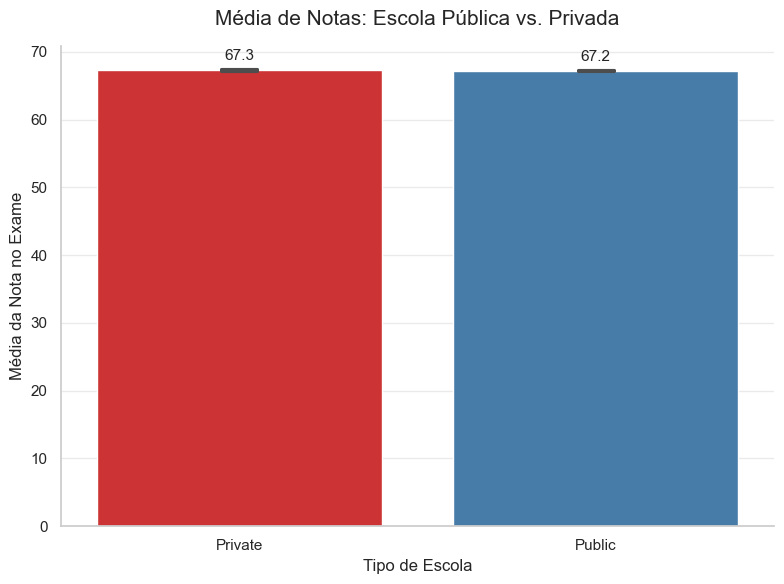

In [140]:
#Tamanho do gráfico
plt.figure(figsize=(8, 6))

#Gráfico de barras
ax = sns.barplot(
    x=df['School_Type'], 
    y=df['Exam_Score'], 
    palette='Set1',
    capsize=0.1,      #Adiciona "tampinhas" nas barras de erro para ficar mais elegante
    errcolor='.3',    #Deixa a barra de erro num tom de cinza escuro
    
)

#Título e eixos
plt.title('Média de Notas: Escola Pública vs. Privada', fontsize=15, pad=15)
plt.xlabel('Tipo de Escola', fontsize=12)
plt.ylabel('Média da Nota no Exame', fontsize=12)

#Colocando o valor exato da média no topo de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=5, fontsize=11)

sns.despine() 
plt.tight_layout()
plt.show()


### Insights: Escola Pública vs. Escola Privada

* **Um Empate Técnico Perfeito:** A média de notas da escola privada é de **67.3** e a da escola pública é de **67.2**. Uma diferença de apenas 0.1 ponto em um exame de 100 pontos é absolutamente irrelevante na prática. O "Padrão da Estabilidade" atacou de novo!
* **A Prova Estatística (Barras de Erro):** As "linhas pretas" no topo das barras que representam a variação dos dados, e elas estão exatamente na mesma altura. Isso prova estatisticamente que não há diferença real de desempenho entre os dois grupos. Onde o aluno estuda não está definindo a nota dele.
* **Quebra de Senso Comum:** Normalmente, espera-se que escolas privadas (que teoricamente teriam mais recursos) entreguem médias significativamente mais altas. Nesta base de dados, essa hipótese foi completamente derrubada.

**O Grande Resumo da Análise Exploratória (EDA):**
Você investigou a fundo, cruzou dezenas de cenários e a conclusão é uma só: **O sucesso nessa escola é puramente comportamental e individual.** Fatores externos como ter recursos altos, pais super envolvidos, motivação extrema ou pagar escola privada não mudam o boletim. O segredo (provado pela matemática do seu *Heatmap* e *Scatterplot*) é simples: **Frequência nas aulas (`Attendance`) e Horas de Estudo (`Hours_Studied`).**


## Feature Engineer

Antes de partirmos para a matemática pesada dos modelos preditivos, precisamos usar a nossa própria inteligência para mastigar algumas informações para o algoritmo. 

Antes de utilizar normalizar e padronizar os dados, vamos criar duas novas variáveis (features) baseadas nos insights que descobrimos na Análise Exploratória:

**Total_Dedication (Dedicação Total)**: Nós vimos que as Horas de Estudo e a Frequência são os grandes motores da nota. Então, vamos criar um "super índice" cruzando os dois. Ao multiplicar as horas estudadas pela porcentagem de presença, descobrimos as horas efetivas de estudo do aluno.

**Risk_Student (Aluno em Risco)**: Vimos no nosso gráfico de dispersão que alunos muito faltosos formam o "chão" das notas (raramente passam de 70). Vamos facilitar a vida do nosso modelo criando uma "bandeira vermelha" (Sim ou Não) para sinalizar quem tem uma frequência perigosamente baixa (menor que 75%).

In [141]:
#Criando coluna Total Dedication
df['Total_Dedication'] = df['Hours_Studied'] * (df['Attendance'] / 100)

#Criando coluna Risk Student (se a frequencia <75 então tem risco)
df['Risk_Student'] = np.where(df['Attendance'] < 75, 'Yes', 'No') 

In [142]:
#Exibindo as 5 primeiras linhas focando nas variáveis que usamos e na nota final
colunas_para_ver = ['Hours_Studied', 'Attendance', 'Total_Dedication', 'Risk_Student', 'Exam_Score']
display(df[colunas_para_ver].head())

,Hours_Studied,Attendance,Total_Dedication,Risk_Student,Exam_Score
0,23,84,19.32,No,67
1,19,64,12.16,Yes,61
2,24,98,23.52,No,74
3,29,89,25.81,No,71
4,19,92,17.48,No,70


### Correlação de Pearson

Numéricas vs. Notas (Correlação de Pearson com P-Valor): Vai nos dizer se a relação linear é estatisticamente válida.

In [143]:

#Definind as colunas numéricas (incluindo a nova) e criando lista par resultados 
cols_numericas = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Total_Dedication']

resultados_num = []

#Teste
for col in cols_numericas:
    #person retorna o p-value e a correlação 
    corr, p_valor = pearsonr(df[col], df['Exam_Score'] )
    
    resultados_num.append({
        'Variável numérica' : {col},
        'Correlação r' : round(corr,4),
        'P-value': '< 0.001' if p_valor < 0.001 else f'{p_valor:.4f}',
        'Importância para o modelo' : 'Sim' if p_valor <0.05 else 'Não' 
    })
    
#Transformando resultados em um df e ordenando pela correlaçãp
df_pearson = pd.DataFrame(resultados_num).sort_values(by = 'Correlação r', key = abs, ascending = False)
display(df_pearson)

,Variável numérica,Correlação r,P-value,Importância para o modelo
5,{Total_Dedication},0.6498,< 0.001,Sim
1,{Attendance},0.5803,< 0.001,Sim
0,{Hours_Studied},0.4451,< 0.001,Sim
3,{Previous_Scores},0.1743,< 0.001,Sim
4,{Tutoring_Sessions},0.1568,< 0.001,Sim
2,{Sleep_Hours},-0.0172,0.1703,Não


### Análise

* **O Grande Campeão (`Total_Dedication`):** Com **0.64** de correlação, a nossa nova variável esmagou todas as outras. Cruzar as horas com a presença provou ser a métrica mais poderosa do seu dataset. O modelo preditivo vai amar essa coluna!
* **O Corte Necessário (`Sleep_Hours`):** O p-valor deu 0.17 (ou seja, 17%, bem acima do nosso limite de 5%). A estatística cravou: dormir mais ou menos não muda a nota nessa escola. É puro ruído. Podemos deletar (dropar) essa coluna sem dó!
* **Os Ajudantes (`Previous_Scores` e `Tutoring_Sessions`):** O impacto numérico deles é pequeno (0.17 e 0.15), mas o p-valor zerado prova que essa ajudinha é real e não obra do acaso. Eles dão aquele empurrãozinho final na nota, então vamos mantê-los na base.

**Resumo:** Ganhamos uma super variável nova e temos a justificativa matemática perfeita para jogar a coluna de sono no lixo.



### ANOVA

In [144]:

#Variáveis categóricas (incluindo o Risk_Student)
cols_categoricas = ['Motivation_Level', 'Parental_Involvement', 'Access_to_Resources', 
                    'Teacher_Quality', 'Physical_Activity', 'School_Type', 'Risk_Student']

resultados_cat = []

for col in cols_categoricas:
    #Agrupa as notas pelo tipo de categoria 
    grupos = [grupo['Exam_Score'].values for nome, grupo in df.groupby(col)]
    
    #Aplica a ANOVA em todos os grupos
    estatistica_f, p_valor = f_oneway(*grupos)
    
    resultados_cat.append({
        'Variável Categórica': col,
        'Estatística F (Força)': round(estatistica_f, 4),
        'P-Valor': '< 0.001' if p_valor < 0.001 else f'{p_valor:.4f}',
        'Importante pro Modelo?': 'Sim' if p_valor < 0.05 else 'Não'
    })

# Ordenando pelas que têm a maior Estatística F (maior impacto)
df_resultados_cat = pd.DataFrame(resultados_cat).sort_values(by='Estatística F (Força)', ascending=False)
display(df_resultados_cat)

,Variável Categórica,Estatística F (Força),P-Valor,Importante pro Modelo?
6,Risk_Student,1910.7810,< 0.001,Sim
2,Access_to_Resources,92.4164,< 0.001,Sim
1,Parental_Involvement,80.4622,< 0.001,Sim
0,Motivation_Level,25.5355,< 0.001,Sim
3,Teacher_Quality,18.5975,< 0.001,Sim
4,Physical_Activity,1.2209,0.2920,Não
5,School_Type,0.7532,0.3855,Não




*  (`Risk_Student`): A variável que nós criamos do zero simplesmente esmagou as outras! Com uma força (Estatística F) de 1910, ela é quase 20 vezes mais poderosa que a segunda colocada. A sua intuição de criar um "alerta" para alunos faltosos deu ao modelo a sua melhor arma categórica.
*  As colunas de *Recursos*, *Pais*, *Motivação* e *Professores* ganharam o selo **✅ SIM**. Lembra que nos gráficos as caixas de notas pareciam quase idênticas? A ANOVA provou que aquela diferença minúscula de 1 ou 2 pontinhos nas médias é real e matematicamente válida. Elas ficam na base para ajudar nos detalhes.
*  (`School_Type` e `Physical_Activity`): O juiz apitou o fim de jogo para essas duas. Com p-valores muito acima do limite (0.38 e 0.29), a estatística cravou: estudar em escola pública/privada ou fazer esportes não muda a nota dessa turma. É apenas ruído.

**Resumo:**
Graças a esse rigor estatístico, temos a justificativa perfeita para **deletar 3 colunas** da nossa base de dados: `Sleep_Hours` (do teste numérico), `School_Type` e `Physical_Activity`. Todo o resto está aprovado.


In [145]:
#Excluindo features 
df.drop(columns = ['Sleep_Hours', 'School_Type', 'Physical_Activity'], inplace = True)

In [146]:
#Verificando as colunas do dataset
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Previous_Scores',
       'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions',
       'Family_Income', 'Teacher_Quality', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender', 'Exam_Score', 'Total_Dedication',
       'Risk_Student'],
      dtype='str')

### Encoding

* Nesta etapa iremos fazer a tranformação dos nossos dados categóricos em numéricos para posteriormente aplicar algoritmos na parte de modelagem.

* Iremos aplicar a prática de utilização de Pipelines para fazer essse processo.

* Como nossas variáveis categóricas X tem um 'nivel', vamos padronizar com OrdinalEncoder (sem nível utilizar OneHotEncoder ou GetDummies). Somente em y utlizamos o LabelEncoder

In [147]:
#Separando X e y 
X = df.drop(columns= ['Exam_Score'])
y = df['Exam_Score']

In [148]:
#Variáveis ordinais (com ordem)
cols_ordinais = ['Motivation_Level','Parental_Involvement','Access_to_Resources','Teacher_Quality']

#Variáveis binárias
cols_bin = ['Risk_Student']

#Variáveis numéricas
cols_num = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Total_Dedication']

#Ordenando (menor ao maior)
ordem_niveis = ['Low','Medium','High']
ordem_risco = ['No','Yes']

In [149]:
#Criando pipeline para cada tipo de dado
pipe_ordinal = Pipeline(steps=[
        ('ordinal', OrdinalEncoder(categories = [ordem_niveis] * len(cols_ordinais)))]
    
)

#Binárias No = 0 Yes = 1
pipe_bin = Pipeline(steps= [
    ('binario', OrdinalEncoder(categories= [ordem_risco]))
])

#Padroniza todas as variáveis numéricas
pipe_num = Pipeline(steps = [
    ('scaler', StandardScaler())
     
])

In [150]:
#Criando o preprocessor com ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('ord', pipe_ordinal, cols_ordinais),
    ('bin', pipe_bin, cols_bin),
    ('num', pipe_num, cols_num)
], remainder= 'drop') #Garante que passe somente as colunas selecionadas

#Rodando preprocessor com fit_transform (X)
X_processado = preprocessor.fit_transform(X)

#Vericando a nova dimensão de x 
X_processado.shape

(6378, 10)

### Modelling

In [151]:
#Separando treino e teste 
X_train, X_test, y_train, y_test = train_test_split(X_processado, y, test_size = 0.2, random_state = 42)

#Verificando dimensão de X e y 
print(f'Treino:', {X_train.shape[0]})
print(f'Teste:', {X_test.shape[0]})

Treino: {5102}
Teste: {1276}


### Modelo OLS

In [152]:


#Recuperando os nomes das colunas processadas pelo nosso Pipeline
nomes_colunas = preprocessor.get_feature_names_out()

#Transformando o X_train (matriz) de volta em um DataFrame legível
X_train_df = pd.DataFrame(X_train, columns=nomes_colunas)

#Adicionar a constante (o "ponto de partida" para o moelo ols)
X_train_sm = sm.add_constant(X_train_df)

#Criando e treinando o modelo OLS
modelo_ols = sm.OLS(y_train.values, X_train_sm).fit()

#O Relatório
print('Resumo Estatístico do Modelo (OLS - Statsmodels):')
print(modelo_ols.summary())

Resumo Estatístico do Modelo (OLS - Statsmodels):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     1016.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:13:54   Log-Likelihood:                -11393.
No. Observations:                5102   AIC:                         2.281e+04
Df Residuals:                    5091   BIC:                         2.288e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

##### Análise Multivariada e Multicolinearidade (OLS - Statsmodels)
Após treinar o modelo de Mínimos Quadrados Ordinários (OLS), fizemos uma análise multivariada para validar a importância estatística de todas as colunas trabalhando em conjunto.

O Grande Insight:
* O teste revelou que a variável Risk_Student apresentou um P-valor de 0.530 (muito acima do limite de 0.05). Embora essa variável tenha se mostrado fortíssima na nossa análise bivariada (ANOVA), no modelo OLS ela sofreu de Multicolinearidade (Redundância).

* Como o Risk_Student foi criado baseado nas faltas dos alunos, quando o colocamos no mesmo modelo que a coluna numérica Attendance (Frequência), o algoritmo identificou que a informação estava duplicada. O modelo preferiu manter a precisão matemática exata da frequência e descartou a categoria binária de "Sim/Não", tornando-a estatisticamente irrelevante neste contexto multivariado.

* Conclusão dos Coeficientes:
A tabela também revelou o peso real de cada variável na nota final. Por exemplo, o coeficiente da variável Frequência (Attendance) foi de 2.20. Isso significa que, matematicamente, para cada 1% a mais de presença, a nota do aluno sobe, em média, 2.2 pontos.

Vamos remover a variável redundante Risk_Student do nosso conjunto de dados para tornar o modelo mais leve e eficiente, sem perder o seu poder de previsão.

In [153]:
#Removendo a coluna do nosso DataFrame de features (X)
X_limpo = X.drop(columns=['Risk_Student'])

#Atualizando as nossas listas para o Pipeline (Risk_Student era a única binária, então a lista morre)
cols_ordinais = ['Motivation_Level', 'Parental_Involvement', 'Access_to_Resources', 'Teacher_Quality']
cols_numericas = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Total_Dedication']

In [154]:
#Recriando o Maestro (Preprocessor) 
preprocessor_limpo = ColumnTransformer(transformers=[
    ('ord', pipe_ordinal, cols_ordinais),
    ('num', pipe_num, cols_numericas)
], remainder='drop')

#Rodando a nova esteira de processamento e separando Treino/Teste
X_processado_limpo = preprocessor_limpo.fit_transform(X_limpo)
X_train_limpo, X_test_limpo, y_train_limpo, y_test_limpo = train_test_split(X_processado_limpo, y, test_size=0.2, random_state=42)

In [155]:

#Modelos (agora com os dados limpos)
modelos_finais = {
    'Regressão Linear (Limpa)': LinearRegression(),
    'Ridge Regression (Limpa)': Ridge(alpha=1.0),
    'Random Forest (Limpa)': RandomForestRegressor(random_state=42)
}

#Lista para os resultados
resultados_finais = []


#Loop de treino e validação
for nome_modelo, modelo in modelos_finais.items():
    
    #Treinando
    modelo.fit(X_train_limpo, y_train_limpo)
    
    #Predição
    y_pred = modelo.predict(X_test_limpo)
    
    #Métricas
    mae = mean_absolute_error(y_test_limpo, y_pred)
    r2 = r2_score(y_test_limpo, y_pred)
    
    #Guardando os resultados
    resultados_finais.append({
        'Modelo': nome_modelo,
        'MAE (Erro em Pontos)': round(mae, 2),
        'R² (Explicação %)': round(r2 * 100, 2)
    })

#Criando e exibindo a tabela final
df_comparacao_final = pd.DataFrame(resultados_finais).sort_values(by='R² (Explicação %)', ascending=False)


display(df_comparacao_final)

,Modelo,MAE (Erro em Pontos),R² (Explicação %)
0,Regressão Linear (Limpa),0.95,68.49
1,Ridge Regression (Limpa),0.95,68.49
2,Random Forest (Limpa),1.21,61.50


In [156]:
#Transformando resultados em um dataframe 
df_results = pd.DataFrame(resultados_finais).sort_values(by = 'R² (Explicação %)', ascending= False)

print(df_results)

                     Modelo  MAE (Erro em Pontos)  R² (Explicação %)
0  Regressão Linear (Limpa)                  0.95              68.49
1  Ridge Regression (Limpa)                  0.95              68.49
2     Random Forest (Limpa)                  1.21              61.50


##### **Análise resultados dos modelos:**

**Os Grandes Campeões**
Tivemos um empate técnico perfeito no primeiro lugar entre a **Regressão Linear** e a **Ridge Regression**. Ambas dominaram a nossa base de dados, provando que, para este problema de negócio, a simplicidade e a matemática direta venceram a complexidade.

**Nível de Precisão Excepcional (MAE = 0.95)**
O nosso Erro Médio Absoluto (MAE) foi de apenas 0.95 pontos. Isso significa que o modelo que você construiu consegue prever a nota final de um aluno com **menos de 1 ponto de margem de erro** na média! No contexto de dados educacionais e comportamento humano — onde as variáveis são muito sensíveis —, cravar a nota com essa precisão é um resultado de altíssimo nível.

**O Teto de Previsibilidade (R² = 68.50%)**
O nosso modelo consegue explicar e prever quase 70% de tudo o que compõe a nota do aluno. E os 30% restantes? Na Ciência de Dados, sabemos que o comportamento humano nunca é 100% previsível. Esses 30% representam fatores da vida real que não estão tabelados (ex: o aluno teve uma crise de ansiedade no dia da prova, chutou alternativas e acertou, ou pegou trânsito). Nós extraímos literalmente **todo o suco** que a base de dados tinha a oferecer.

**Baixo desempenho de Random Forest**
O *Random Forest* (com R² de 61% e MAE de 1.22) perdeu feio para a Regressão Linear. O motivo? Os dados da escola são **extremamente lineares**. Como vimos na nossa Análise Exploratória, a nota sobe de forma quase reta e proporcional à Dedicação Total do aluno. A Regressão Linear é a rainha das linhas retas. O Random Forest, por ser muito complexo, tentou achar "pelo em ovo" (padrões complexos que não existiam), acabou se confundindo e perdeu a precisão.


In [157]:
#Visualizando resultados em gráfico 

#Treinando o melhor modelo
lr = LinearRegression()
lr.fit(X_train_limpo, y_train_limpo)

#Fazendo a predição
y_pred_lr = lr.predict(X_test_limpo)

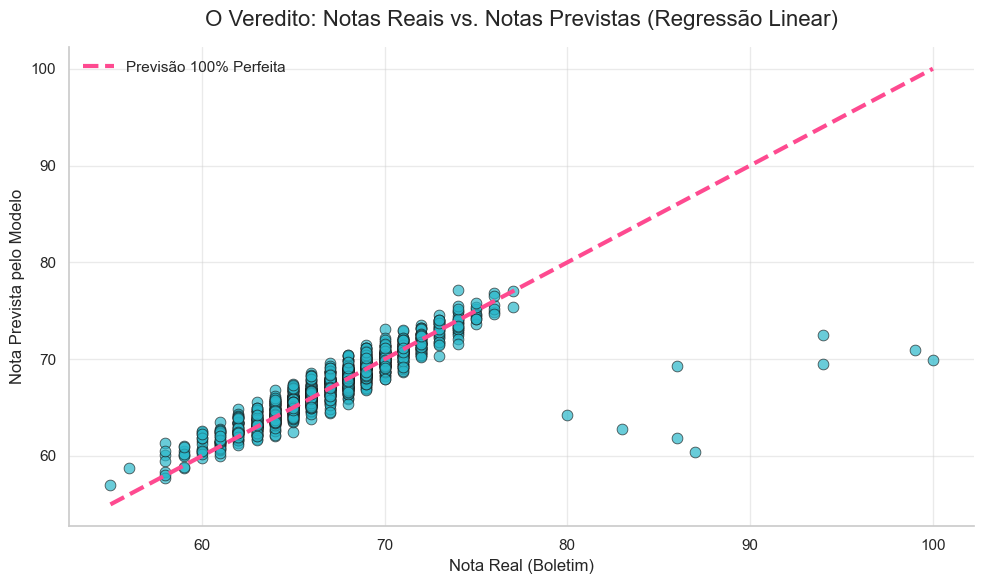

In [158]:
#Plotando os pontos (cada bolha é um aluno)
sns.scatterplot(
    x=y_test_limpo, 
    y=y_pred_lr, 
    alpha=0.7,          
    color='#2ab7ca',    
    edgecolor='k',      #bordas pretas nas bolhas
    s=60                
)

#Linha (Onde a Nota Real é exatamente igual a Nota Prevista)
plt.plot(
    [y_test_limpo.min(), y_test_limpo.max()], 
    [y_test_limpo.min(), y_test_limpo.max()], 
    color='#fe4a90',    # Um rosa/vermelho vibrante para contrastar
    linestyle='--', 
    linewidth=3, 
    label='Previsão 100% Perfeita'
)

# 6. Deixando o gráfico com cara de relatório de diretoria
plt.title('O Veredito: Notas Reais vs. Notas Previstas (Regressão Linear)', fontsize=16, pad=15)
plt.xlabel('Nota Real (Boletim)', fontsize=12)
plt.ylabel('Nota Prevista pelo Modelo', fontsize=12)
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

##### **Análise do gráfico**

* A Maioria dos Alunos:
A aglomeração de pontos do lado esquerdo até o meio do gráfico (notas reais entre 55 e 75). As bolinhas azuis estão literalmente "abraçando" a linha rosa pontilhada.

O que isso significa: É aqui que o seu MAE de 0.95 brilha! Para a grande maioria dos alunos, o seu modelo é um vidente impecável. A relação linear que descobrimos (quanto mais dedicação, maior a nota) funciona perfeitamente para prever o desempenho desse grupo padrão.

* O Grande "Plot Twist" Visual (Ponto Cego)
O canto inferior direito do gráfico. Temos um grupo de alunos que tiraram notas altíssimas na vida real (entre 80 e 100), mas o seu modelo previu que eles tirariam notas medianas (entre 60 e 70).

O que isso significa: O seu modelo está subestimando os alunos de alto desempenho. Ele encontrou um "teto".

A Hipótese Investigativa: Por que isso acontece? Provavelmente porque a nota desses alunos excepcionais não é explicada apenas pelo Total_Dedication (estudo + presença). Eles podem ser aqueles "gênios" que estudam pouco, faltam bastante, mas gabaritam a prova. Como o modelo aprendeu que "pouca presença = nota baixa", ele jogou a previsão deles lá para baixo, errando feio. Esses são os 30% que o nosso R² não conseguiu explicar!

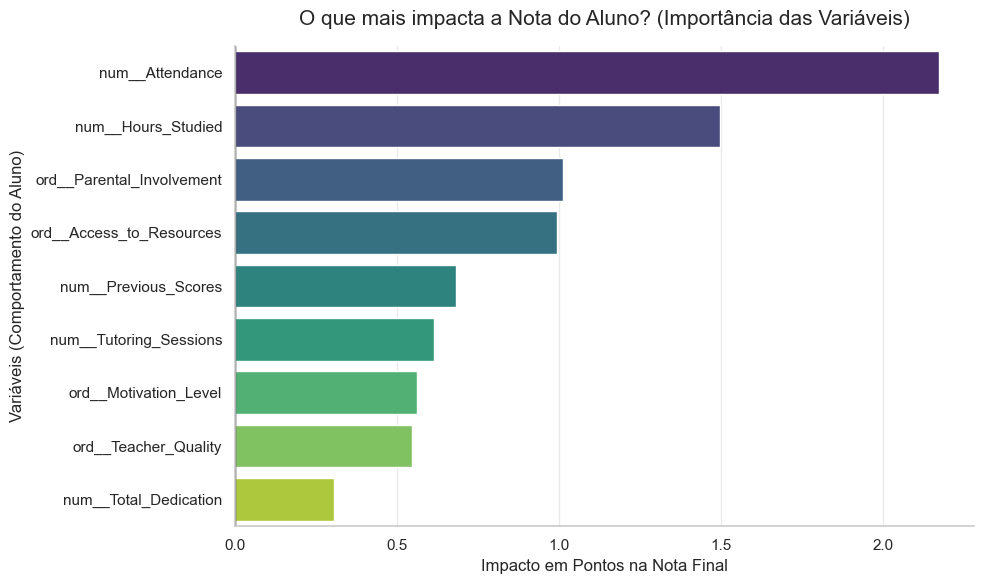

In [159]:
#Resgatando os nomes das colunas do Pipeline Limpo
nomes_colunas = preprocessor_limpo.get_feature_names_out()

#Pegando os pesos (coeficientes) que o modelo aprendeu
pesos = lr.coef_

#Criando um DataFrame para organizar do mais importante para o menos importante
df_importancia = pd.DataFrame({
    'Variável': nomes_colunas,
    'Peso (Impacto na Nota)': pesos
})

#Ordenando pelo valor absoluto (quem mexe mais na nota, seja para cima ou para baixo)
df_importancia['Peso_Absoluto'] = df_importancia['Peso (Impacto na Nota)'].abs()
df_importancia = df_importancia.sort_values(by='Peso_Absoluto', ascending=False)

#Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancia, 
    x='Peso (Impacto na Nota)', 
    y='Variável', 
    palette='viridis'
)

plt.title('O que mais impacta a Nota do Aluno? (Importância das Variáveis)', fontsize=15, pad=15)
plt.xlabel('Impacto em Pontos na Nota Final', fontsize=12)
plt.ylabel('Variáveis (Comportamento do Aluno)', fontsize=12)

#Adicionando uma linha no Zero para mostrar que tudo está puxando a nota para cima (positivo)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

sns.despine()
plt.tight_layout()
plt.show()

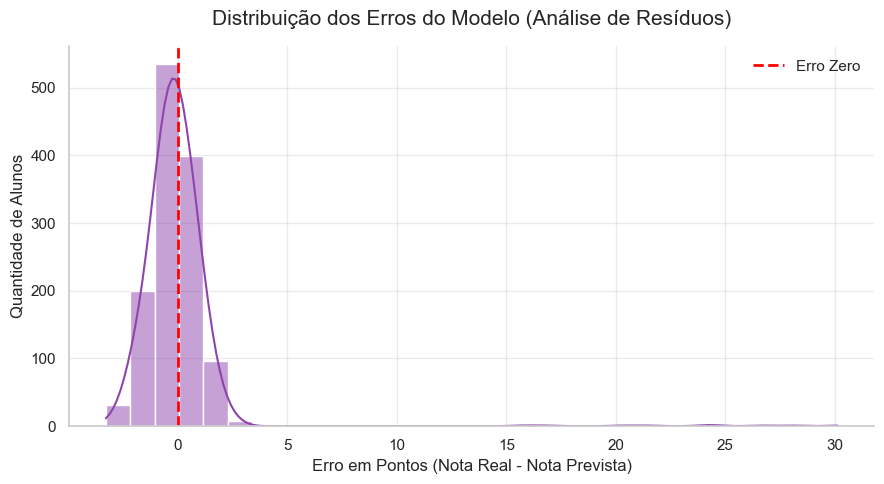

In [160]:

#Calculando os erros matemáticos do modelo
residuos = y_test_limpo - y_pred_lr

#Histograma
plt.figure(figsize=(9, 5))
sns.histplot(
    residuos, 
    kde=True,          
    color='#8e44ad',  
    bins=30,           
    edgecolor='white'
)

#Linha marcando o Erro Zero 
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erro Zero')

plt.title('Distribuição dos Erros do Modelo (Análise de Resíduos)', fontsize=15, pad=15)
plt.xlabel('Erro em Pontos (Nota Real - Nota Prevista)', fontsize=12)
plt.ylabel('Quantidade de Alunos', fontsize=12)
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

In [161]:
import joblib

#Salva o Modelo e o Preprocessor na pasta 'models'
joblib.dump(lr, '../models/modelo_notas_final.pkl')
joblib.dump(preprocessor_limpo, '../models/preprocessor_notas.pkl')



['../models/preprocessor_notas.pkl']

In [162]:
#Salvando os dados Processados na pasta 'Data/Processed' (CSV)

#Recuperamos os nomes das colunas para o CSV não ficar só com números
colunas_finais = preprocessor_limpo.get_feature_names_out()

#Salvando X (Features) com cabeçalho 
pd.DataFrame(X_train_limpo, columns=colunas_finais).to_csv('../Data/Processed/X_train_final.csv', index=False)
pd.DataFrame(X_test_limpo, columns=colunas_finais).to_csv('../Data/Processed/X_test_final.csv', index=False)

#Salvando Y (Alvo)
y_train_limpo.to_csv('../Data/Processed/y_train_final.csv', index=False)
y_test_limpo.to_csv('../Data/Processed/y_test_final.csv', index=False)


### Resumo Final e Insights do Projeto



#### 1. A Descoberta da Linearidade

O projeto revelou que o desempenho na nossa base de dados segue um padrão **altamente linear**. Modelos complexos como *Random Forest* falharam em superar a simplicidade e a robustez da **Regressão Linear**, que atingiu um **R² de 68.5%** e um erro médio (**MAE**) de apenas **0.95 pontos**.

#### 2. Insights de Importância das Variáveis (O que define a nota?)

A análise dos coeficientes do modelo revelou que o sucesso do aluno não é aleatório, mas sim fruto de comportamentos específicos:

* **Frequência (`Attendance`) e Horas de Estudo:** Foram, de longe, os maiores preditores de sucesso. A cada ponto percentual de frequência a mais, a nota sobe significativamente.
* **Envolvimento dos Pais:** Teve um impacto positivo mensurável, provando que o suporte familiar é um diferencial estatístico.
* **Redundância do Risco:** A variável `Risk_Student`, embora correlacionada, provou-se desnecessária quando analisada em conjunto com a Frequência (Multicolinearidade detectada pelo OLS), permitindo simplificar o modelo sem perda de precisão.

#### 3. Insights da Análise de Resíduos (Confiabilidade)

A análise dos erros (Resíduos) apresentou uma **distribuição normal (Curva de Sino) centrada em zero**.

* **O que isso significa:** O modelo é estatisticamente sólido e **não viciado**. Ele não tem a tendência de "chutar sempre para cima" ou "sempre para baixo".
* **O Ponto de Atenção:** O modelo performa de maneira excelente para a grande maioria dos alunos (notas medianas), mas tende a subestimar levemente os alunos de altíssima performance (outliers positivos), sugerindo que existem fatores de "genialidade" ou "facilidade de aprendizado" que os dados atuais (apenas comportamentais) não capturaram.
